# Drift Triage â€” Phase 1: Dataset & Model Training
UCI Bank Marketing dataset exploration, preprocessing, training, and MLflow registration.

## 1. Load & Clean

In [1]:
import os
from pathlib import Path
import kagglehub
import pandas as pd
import numpy as np

TARGET = "y"
DROP_COLS = ["duration"]   # leaks target â€” drop immediately
PDAYS_SENTINEL = 999

# Download dataset from Kaggle (cached after first download)
dataset_dir = Path(kagglehub.dataset_download("sahistapatel96/bankadditionalfullcsv"))
csv_path = next(dataset_dir.rglob("bank-additional-full.csv"))
print(f"Dataset path: {csv_path}")

df = pd.read_csv(csv_path, sep=";")
print(f"Raw shape: {df.shape}")
df.head()

c:\Users\Kayan\OneDrive\Desktop\SE Factory\drift-triage-copilot\training\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\Kayan\.cache\kagglehub\datasets\sahistapatel96\bankadditionalfullcsv\versions\1\bank-additional-full.csv
Raw shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
# Normalize column names (dataset uses dots: emp.var.rate â†’ emp_var_rate)
df.columns = df.columns.str.replace(".", "_", regex=False)

# Drop duration (data leakage)
df = df.drop(columns=DROP_COLS)

# pdays sentinel: 999 means never contacted â€” encode as binary flag
df["pdays_contacted"] = (df["pdays"] != PDAYS_SENTINEL).astype(int)
df = df.drop(columns=["pdays"])

# Encode target
df[TARGET] = (df[TARGET] == "yes").astype(int)

print(f"Cleaned shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Positive rate: {df[TARGET].mean():.4f}")
df.head()

Cleaned shape: (41188, 20)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'pdays_contacted']
Positive rate: 0.1127


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,pdays_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0


## 2. Explore

In [3]:
df.dtypes

age                  int64
job                 object
marital             object
education           object
default             object
housing             object
loan                object
contact             object
month               object
day_of_week         object
campaign             int64
previous             int64
poutcome            object
emp_var_rate       float64
cons_price_idx     float64
cons_conf_idx      float64
euribor3m          float64
nr_employed        float64
y                    int64
pdays_contacted      int64
dtype: object

In [4]:
# Check 'unknown' appears as a real category (do NOT impute)
for col in df.select_dtypes(include="object").columns:
    if "unknown" in df[col].values:
        print(f"{col}: {df[col].value_counts().to_dict()}")

job: {'admin.': 10422, 'blue-collar': 9254, 'technician': 6743, 'services': 3969, 'management': 2924, 'retired': 1720, 'entrepreneur': 1456, 'self-employed': 1421, 'housemaid': 1060, 'unemployed': 1014, 'student': 875, 'unknown': 330}
marital: {'married': 24928, 'single': 11568, 'divorced': 4612, 'unknown': 80}
education: {'university.degree': 12168, 'high.school': 9515, 'basic.9y': 6045, 'professional.course': 5243, 'basic.4y': 4176, 'basic.6y': 2292, 'unknown': 1731, 'illiterate': 18}
default: {'no': 32588, 'unknown': 8597, 'yes': 3}
housing: {'yes': 21576, 'no': 18622, 'unknown': 990}
loan: {'no': 33950, 'yes': 6248, 'unknown': 990}


In [5]:
# Class imbalance
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True))

y
0    36548
1     4640
Name: count, dtype: int64
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64


In [6]:
df.describe()

,age,campaign,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,pdays_contacted
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654,0.036783
std,10.42125,2.770014,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173,0.188230
min,17.00000,1.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000
25%,32.00000,1.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,0.000000
50%,38.00000,2.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,0.000000
75%,47.00000,3.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000
max,98.00000,56.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000


## 2b. EDA — Numeric Feature Distributions

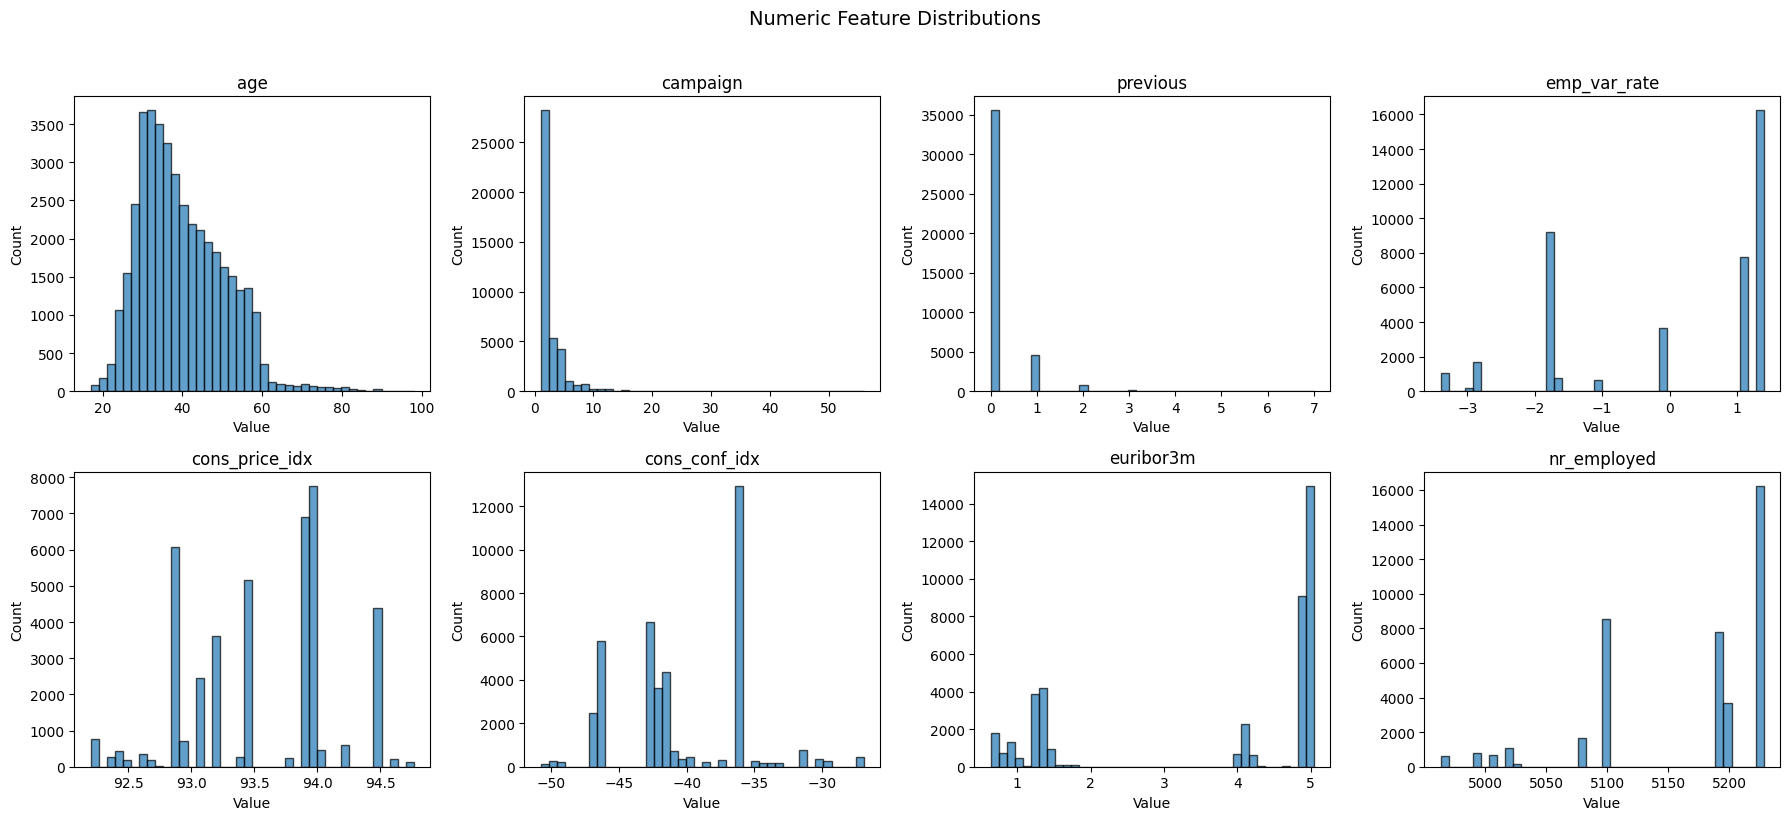

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

NUMERIC_COLS_EDA = [
    "age", "campaign", "previous",
    "emp_var_rate", "cons_price_idx", "cons_conf_idx",
    "euribor3m", "nr_employed",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS_EDA):
    axes[i].hist(df[col], bins=40, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Numeric Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2c. EDA — Categorical Feature Distributions

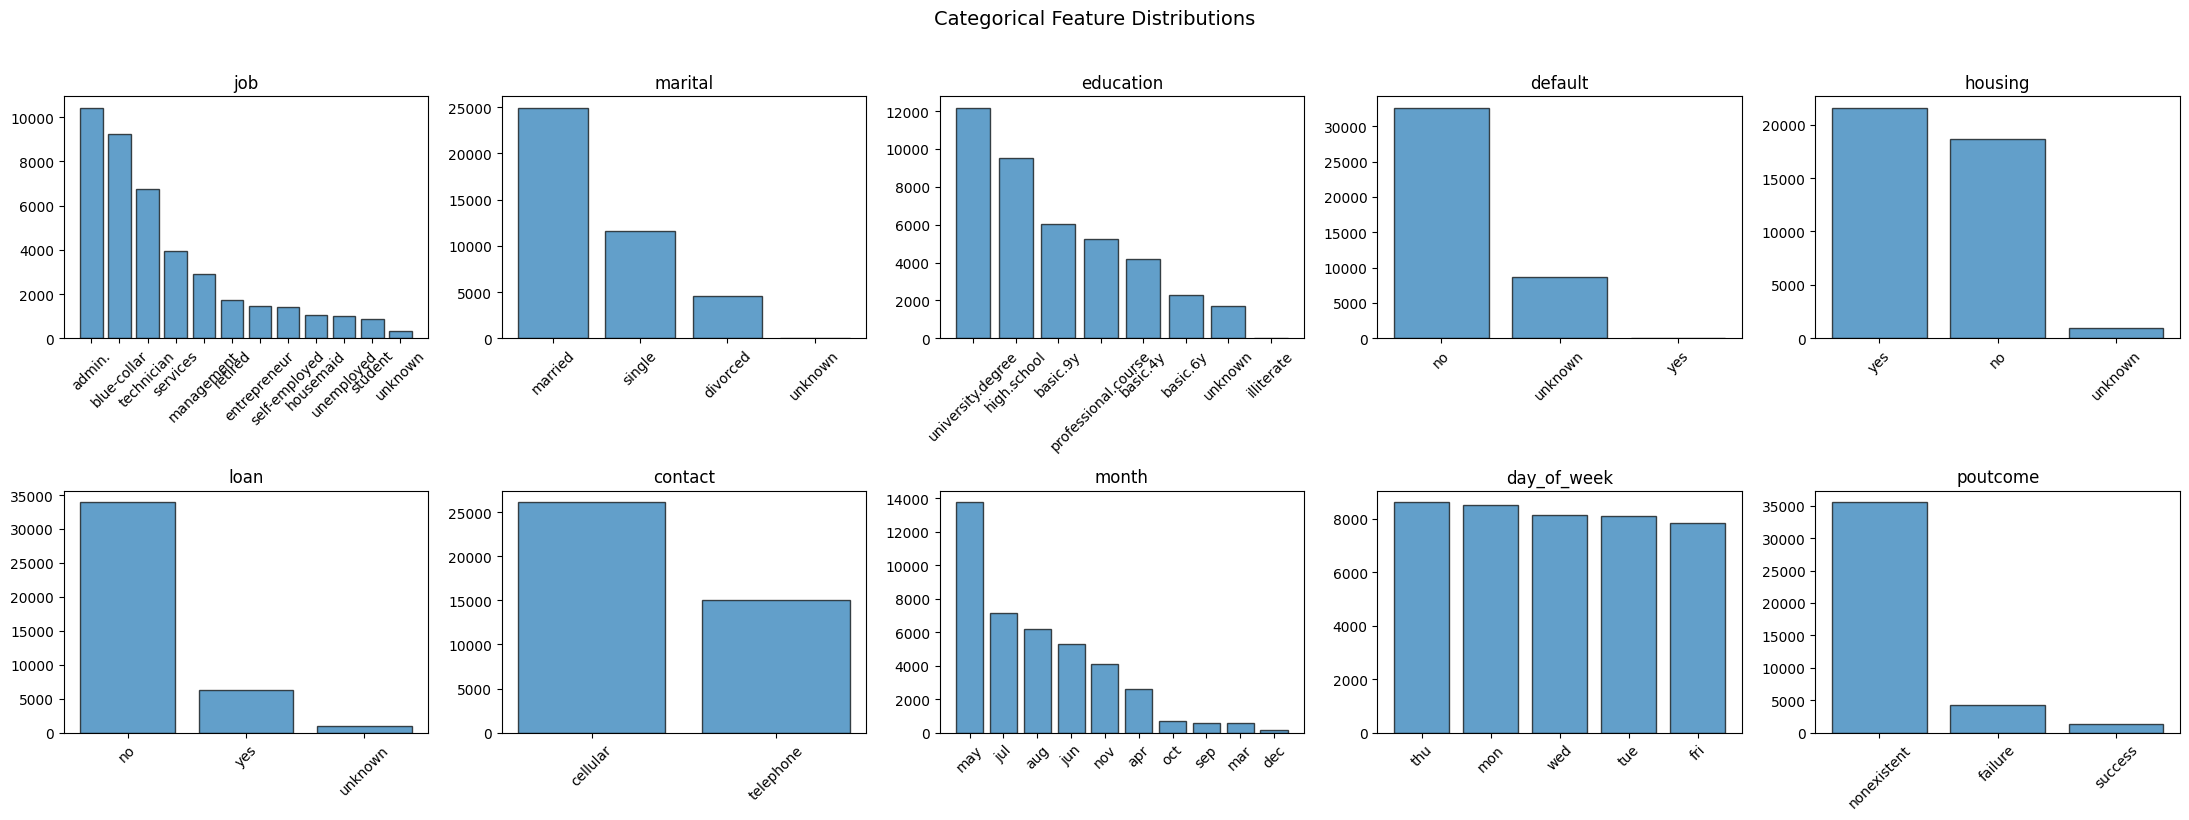

In [8]:
CAT_COLS_EDA = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month",
    "day_of_week", "poutcome",
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS_EDA):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle("Categorical Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2d. EDA — Class Imbalance

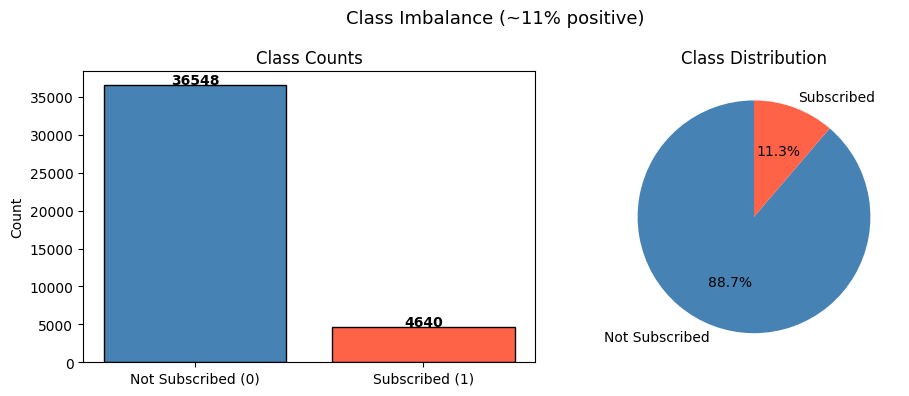

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df[TARGET].value_counts()
axes[0].bar(["Not Subscribed (0)", "Subscribed (1)"], counts.values,
            color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Count")
for j, v in enumerate(counts.values):
    axes[0].text(j, v + 100, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=["Not Subscribed", "Subscribed"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Class Distribution")

plt.suptitle("Class Imbalance (~11% positive)", fontsize=13)
plt.tight_layout()
plt.show()

## 2e. EDA — Correlation Heatmap (Numeric Features)

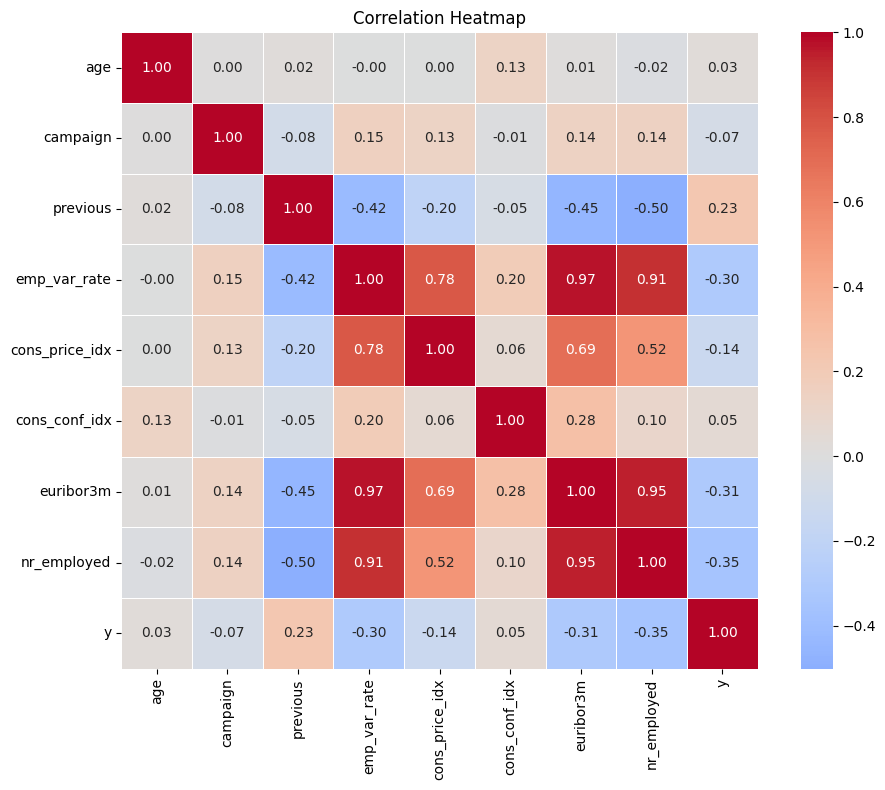

In [10]:
corr_cols = NUMERIC_COLS_EDA + [TARGET]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 2f. EDA — Target Rate by Feature

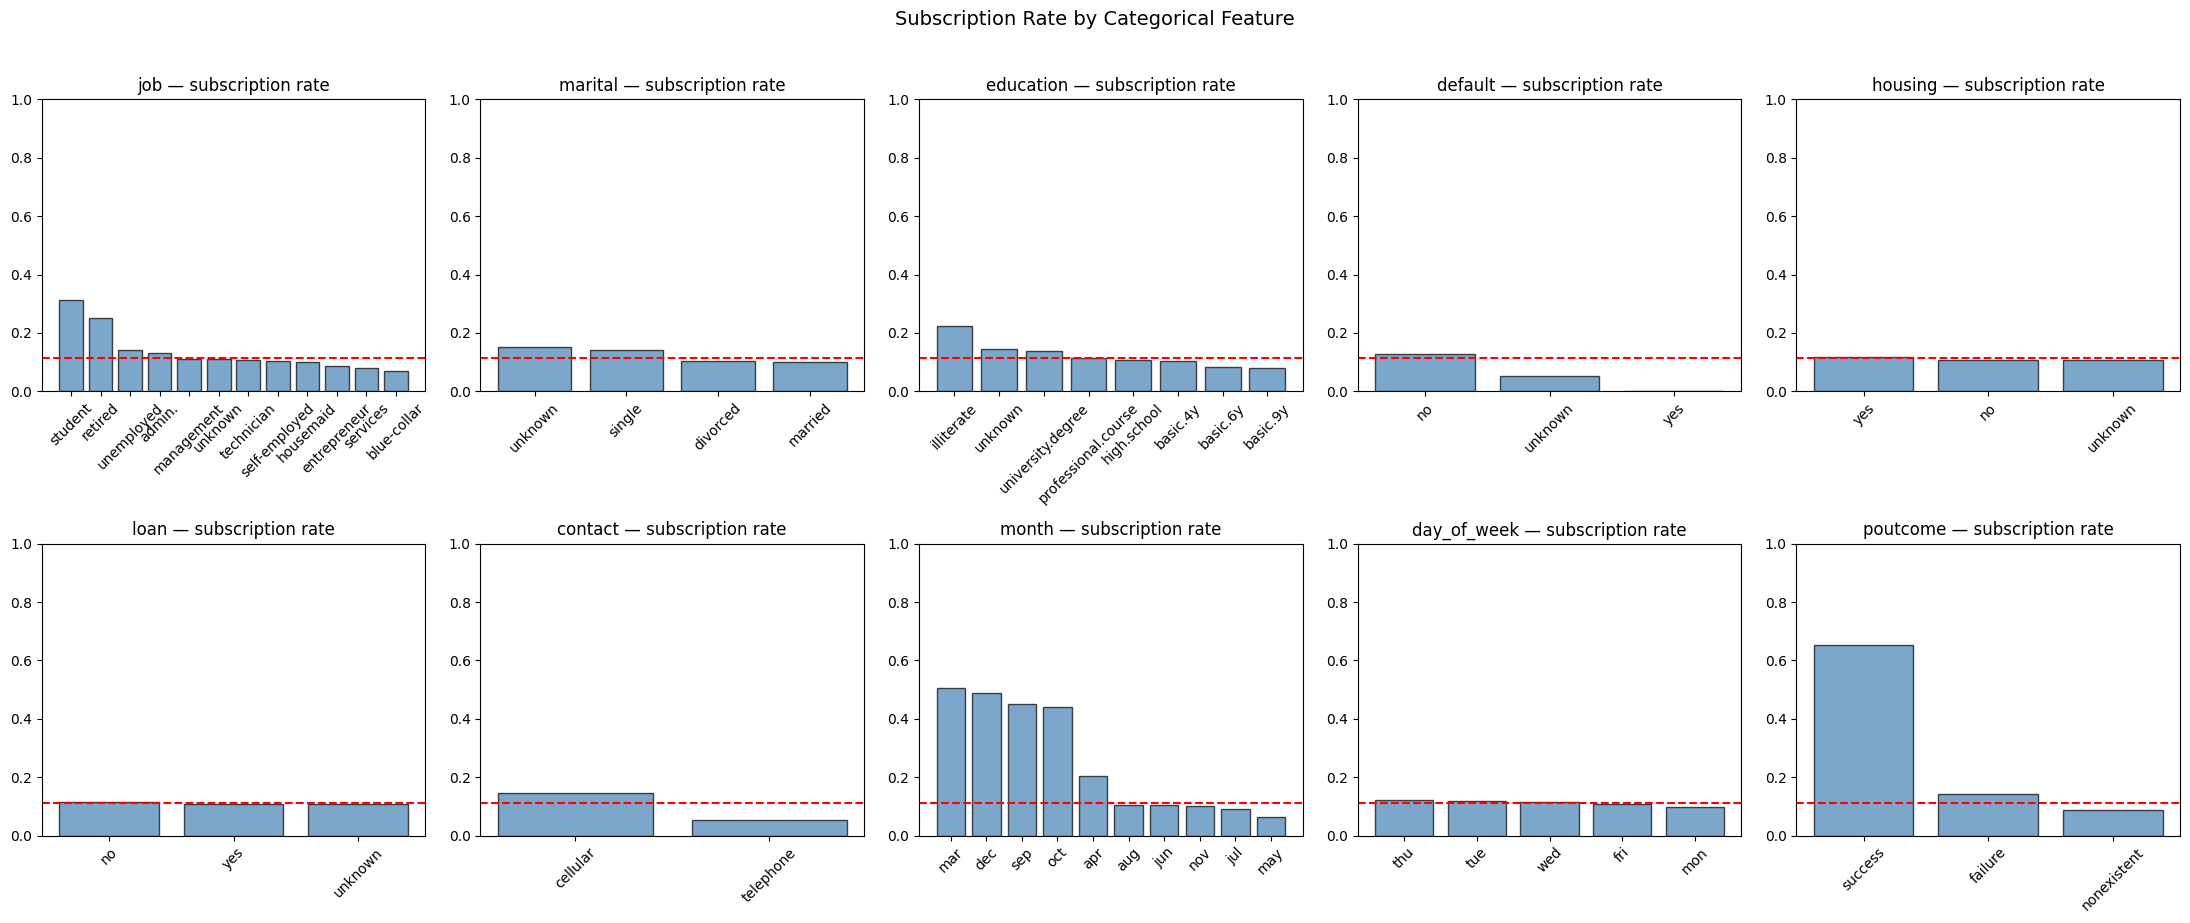

In [11]:
# Subscription rate by categorical feature
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS_EDA):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    axes[i].bar(rate.index, rate.values, edgecolor="black", alpha=0.7, color="steelblue")
    axes[i].axhline(df[TARGET].mean(), color="red", linestyle="--", label="Overall avg")
    axes[i].set_title(f"{col} — subscription rate")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].set_ylim(0, 1)

plt.suptitle("Subscription Rate by Categorical Feature", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

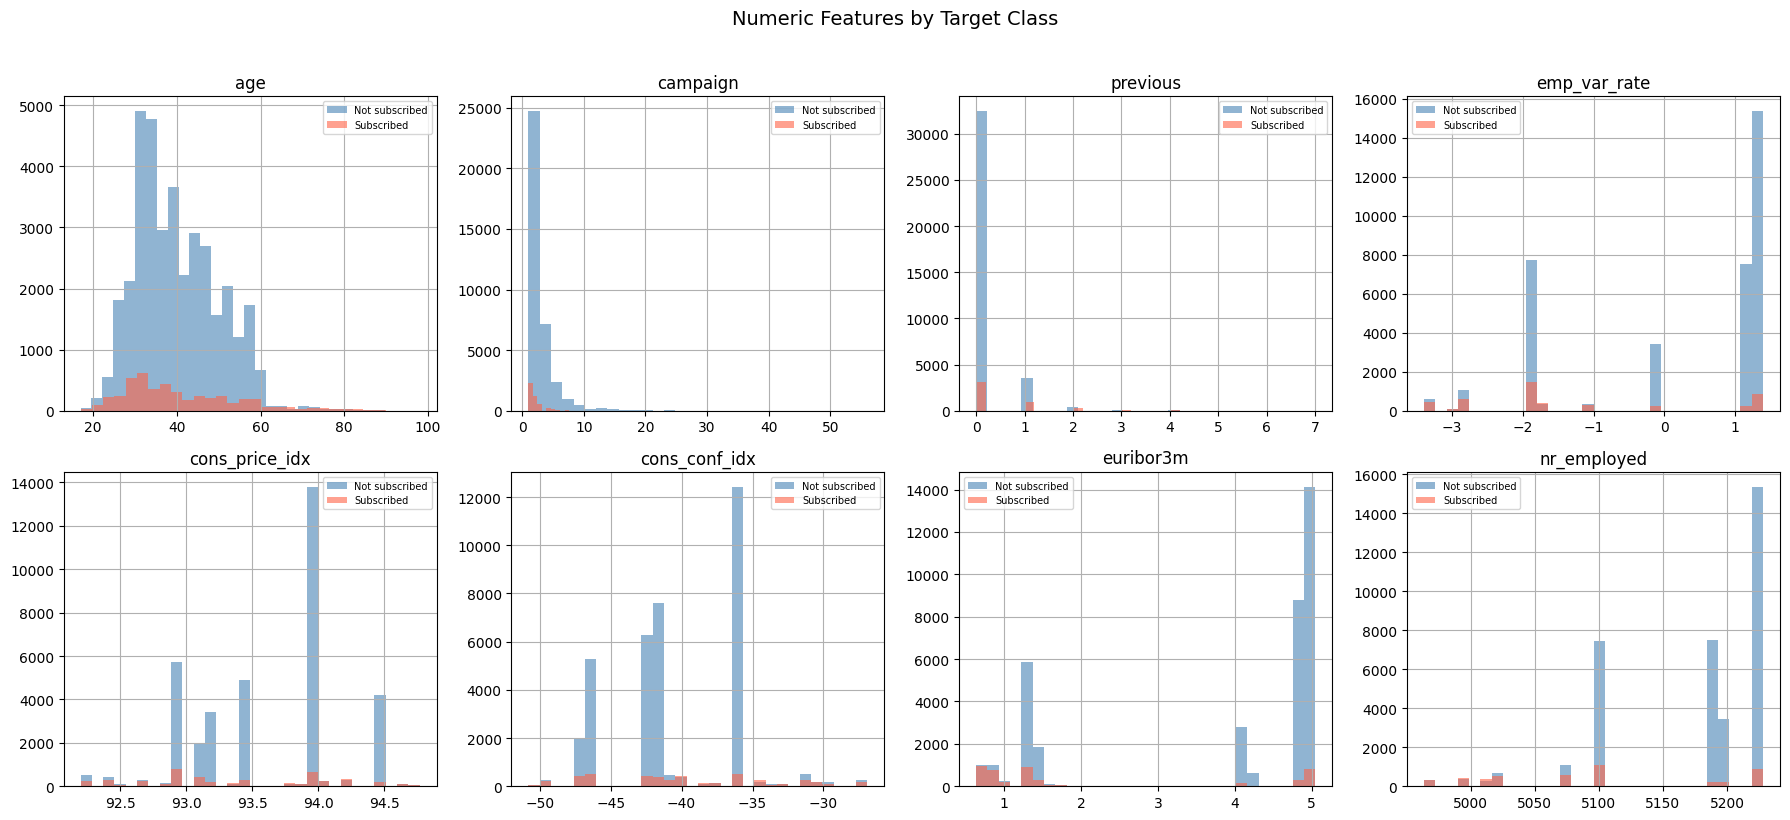

In [12]:
# Distribution of numeric features split by target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS_EDA):
    df[df[TARGET] == 0][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                   label="Not subscribed", color="steelblue")
    df[df[TARGET] == 1][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                   label="Subscribed", color="tomato")
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle("Numeric Features by Target Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Feature Split

In [13]:
NUMERIC_COLS = [
    "age", "campaign", "previous", "pdays_contacted",
    "emp_var_rate", "cons_price_idx", "cons_conf_idx",
    "euribor3m", "nr_employed",
]

CAT_COLS = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month",
    "day_of_week", "poutcome",
]

print("Numeric:", NUMERIC_COLS)
print("Categorical:", CAT_COLS)
print(f"Total features: {len(NUMERIC_COLS) + len(CAT_COLS)}")

Numeric: ['age', 'campaign', 'previous', 'pdays_contacted', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Total features: 19


## 4. Train/Val/Test Split (60/20/20, stratified)

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Val positive rate:   {y_val.mean():.4f}")
print(f"Test positive rate:  {y_test.mean():.4f}")

Train: 24712 | Val: 8238 | Test: 8238
Train positive rate: 0.1127
Val positive rate:   0.1126
Test positive rate:  0.1126


## 4b. Model Comparison
Train four candidates on the same split, compare val AUC + recall. Pick the winner before tuning.

In [15]:
import time
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def make_pipeline(classifier):
    pre = ColumnTransformer(transformers=[
        ("num", StandardScaler(), NUMERIC_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
    ])
    return Pipeline(steps=[("preprocessor", pre), ("classifier", classifier)])

candidates = {
    "RandomForest":               RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "GradientBoosting":           GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    "HistGradientBoosting":       HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=4, random_state=42),
}

results = []
trained_models = {}

for name, clf in candidates.items():
    t0 = time.time()
    pipe = make_pipeline(clf)
    pipe.fit(X_train, y_train)
    elapsed = round(time.time() - t0, 1)

    val_probs = pipe.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)

    # threshold at 0.5 for quick comparison
    val_preds = (val_probs >= 0.5).astype(int)
    val_recall = recall_score(y_val, val_preds, zero_division=0)
    val_f1 = f1_score(y_val, val_preds, zero_division=0)

    results.append({
        "model": name,
        "val_auc": round(val_auc, 4),
        "val_recall@0.5": round(val_recall, 4),
        "val_f1@0.5": round(val_f1, 4),
        "train_time_s": elapsed,
    })
    trained_models[name] = pipe
    print(f"{name}: AUC={val_auc:.4f}  recall={val_recall:.4f}  ({elapsed}s)")

comparison_df = pd.DataFrame(results).sort_values('val_auc', ascending=False)
comparison_df

RandomForest: AUC=0.7801  recall=0.2629  (1.0s)
GradientBoosting: AUC=0.8068  recall=0.2543  (8.9s)
HistGradientBoosting: AUC=0.8092  recall=0.2489  (2.7s)


,model,val_auc,val_recall@0.5,val_f1@0.5,train_time_s
2,HistGradientBoosting,0.8092,0.2489,0.3655,2.7
1,GradientBoosting,0.8068,0.2543,0.3685,8.9
0,RandomForest,0.7801,0.2629,0.3529,1.0


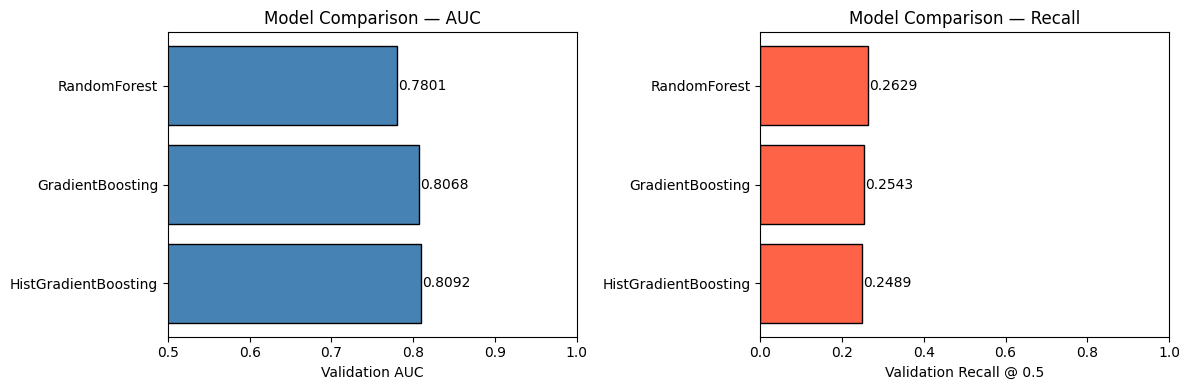

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(comparison_df['model'], comparison_df['val_auc'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Validation AUC')
axes[0].set_title('Model Comparison — AUC')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(comparison_df['val_auc']):
    axes[0].text(v + 0.002, i, str(v), va='center')

axes[1].barh(comparison_df['model'], comparison_df['val_recall@0.5'], color='tomato', edgecolor='black')
axes[1].set_xlabel('Validation Recall @ 0.5')
axes[1].set_title('Model Comparison — Recall')
axes[1].set_xlim(0, 1.0)
for i, v in enumerate(comparison_df['val_recall@0.5']):
    axes[1].text(v + 0.002, i, str(v), va='center')

plt.tight_layout()
plt.show()

In [17]:
# Pick the best model by AUC
best_model_name = comparison_df.iloc[0]['model']
print(f'Best model: {best_model_name}')
print(comparison_df.iloc[0])

Best model: HistGradientBoosting
model             HistGradientBoosting
val_auc                         0.8092
val_recall@0.5                  0.2489
val_f1@0.5                      0.3655
train_time_s                       2.7
Name: 2, dtype: object


## 4b2. SMOTE Oversampling
Apply SMOTE only to the training set to balance the 11% positive class.
Val and test sets are never touched — doing so would be data leakage.

In [18]:
print(f'Before SMOTE — train class distribution:')
print(y_train.value_counts())
print(f'Positive rate: {y_train.mean():.4f}')

Before SMOTE — train class distribution:
y
0    21928
1     2784
Name: count, dtype: int64
Positive rate: 0.1127


In [19]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score, precision_score

def make_smote_pipeline(classifier):
    pre = ColumnTransformer(transformers=[
        ("num", StandardScaler(), NUMERIC_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
    ])
    # imblearn Pipeline — SMOTE only runs during fit(), not predict()
    return ImbPipeline(steps=[
        ("preprocessor", pre),
        ("smote", SMOTE(random_state=42)),
        ("classifier", classifier),
    ])

# Option 1: HistGBM + SMOTE
smote_pipe = make_smote_pipeline(
    HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                   max_depth=4, random_state=42)
)
smote_pipe.fit(X_train, y_train)
print("HistGBM + SMOTE trained")

# Option 2: HistGBM + class_weight='balanced' (native HistGBM support)
balanced_pipe = make_pipeline(
    HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                   max_depth=4, class_weight="balanced",
                                   random_state=42)
)
balanced_pipe.fit(X_train, y_train)
print("HistGBM + class_weight=balanced trained")

HistGBM + SMOTE trained
HistGBM + class_weight=balanced trained


In [20]:
# Compute val probs for all three variants
base_pipe = trained_models["HistGradientBoosting"]
base_val_probs     = base_pipe.predict_proba(X_val)[:, 1]
smote_val_probs    = smote_pipe.predict_proba(X_val)[:, 1]
balanced_val_probs = balanced_pipe.predict_proba(X_val)[:, 1]

def find_threshold(probs, y, min_recall=0.75):
    for t in np.arange(0.95, 0.00, -0.01):
        threshold = round(float(t), 2)
        preds = (probs >= threshold).astype(int)
        if recall_score(y, preds, zero_division=0) >= min_recall:
            return threshold
    return 0.5

baseline_threshold = find_threshold(base_val_probs, y_val)
smote_threshold    = find_threshold(smote_val_probs, y_val)
balanced_threshold = find_threshold(balanced_val_probs, y_val)

print(f"Baseline threshold:     {baseline_threshold}")
print(f"SMOTE threshold:        {smote_threshold}")
print(f"class_weight threshold: {balanced_threshold}")

Baseline threshold:     0.07
SMOTE threshold:        0.15
class_weight threshold: 0.37


In [21]:
# Compare all three variants side by side
base_preds     = (base_val_probs     >= baseline_threshold).astype(int)
smote_preds    = (smote_val_probs    >= smote_threshold).astype(int)
balanced_preds = (balanced_val_probs >= balanced_threshold).astype(int)

def metrics_row(name, probs, preds, threshold):
    return {
        "model":         name,
        "threshold":     threshold,
        "val_auc":       round(roc_auc_score(y_val, probs), 4),
        "val_recall":    round(recall_score(y_val, preds, zero_division=0), 4),
        "val_precision": round(precision_score(y_val, preds, zero_division=0), 4),
        "val_f1":        round(f1_score(y_val, preds, zero_division=0), 4),
    }

compare = pd.DataFrame([
    metrics_row("HistGBM baseline",       base_val_probs,     base_preds,     baseline_threshold),
    metrics_row("HistGBM + SMOTE",        smote_val_probs,    smote_preds,    smote_threshold),
    metrics_row("HistGBM + class_weight", balanced_val_probs, balanced_preds, balanced_threshold),
])
compare

,model,threshold,val_auc,val_recall,val_precision,val_f1
0,HistGBM baseline,0.07,0.8092,0.7662,0.2442,0.3703
1,HistGBM + SMOTE,0.15,0.8003,0.7619,0.2330,0.3569
2,HistGBM + class_weight,0.37,0.8089,0.7608,0.2579,0.3853


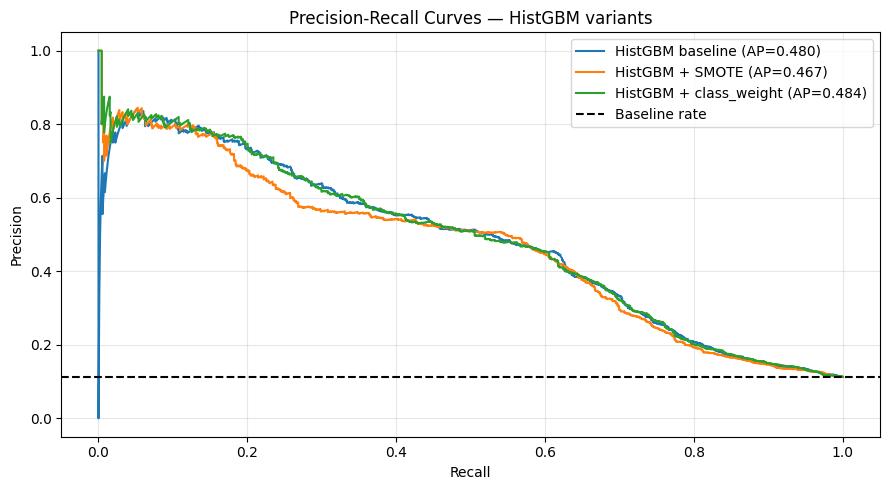

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(9, 5))
for label, probs in [
    ("HistGBM baseline",       base_val_probs),
    ("HistGBM + SMOTE",        smote_val_probs),
    ("HistGBM + class_weight", balanced_val_probs),
]:
    p, r, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)
    plt.plot(r, p, label=f"{label} (AP={ap:.3f})")

plt.axhline(y_val.mean(), color="black", linestyle="--", label="Baseline rate")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — HistGBM variants")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Pick winner: must meet promotion gate (AUC >= 0.75 AND recall >= 0.75)
# Among eligible models, prefer the highest threshold (most conservative)
MIN_AUC    = 0.75
MIN_RECALL = 0.75

eligible = compare[
    (compare["val_auc"]    >= MIN_AUC) &
    (compare["val_recall"] >= MIN_RECALL)
].copy()

if eligible.empty:
    # fallback: relax recall, just meet AUC
    eligible = compare[compare["val_auc"] >= MIN_AUC]
    print("WARNING: no variant met both AUC >= 0.75 and recall >= 0.75")
    print("Falling back to AUC-only filter — consider retraining")

if eligible.empty:
    # last resort: best AUC regardless
    best_row = compare.loc[compare["val_auc"].idxmax()]
    print("WARNING: no variant met AUC >= 0.75 either — check your model")
else:
    # among eligible, pick highest threshold (most conservative predictor)
    best_row = eligible.loc[eligible["threshold"].idxmax()]

best_name = best_row["model"]

pipe_map = {
    "HistGBM baseline":       (base_pipe,     baseline_threshold),
    "HistGBM + SMOTE":        (smote_pipe,    smote_threshold),
    "HistGBM + class_weight": (balanced_pipe, balanced_threshold),
}

pipeline, operating_threshold = pipe_map[best_name]
print(f"Winner: {best_name}")
print(f"AUC={best_row['val_auc']}  recall={best_row['val_recall']}  threshold={operating_threshold}")
print("pipeline and operating_threshold set for downstream cells")

Winner: HistGBM + class_weight
AUC=0.8089  recall=0.7608  threshold=0.37
pipeline and operating_threshold set for downstream cells


## 4c. Precision-Recall Curves
Compare all models on the val set — helps understand threshold behaviour before tuning.

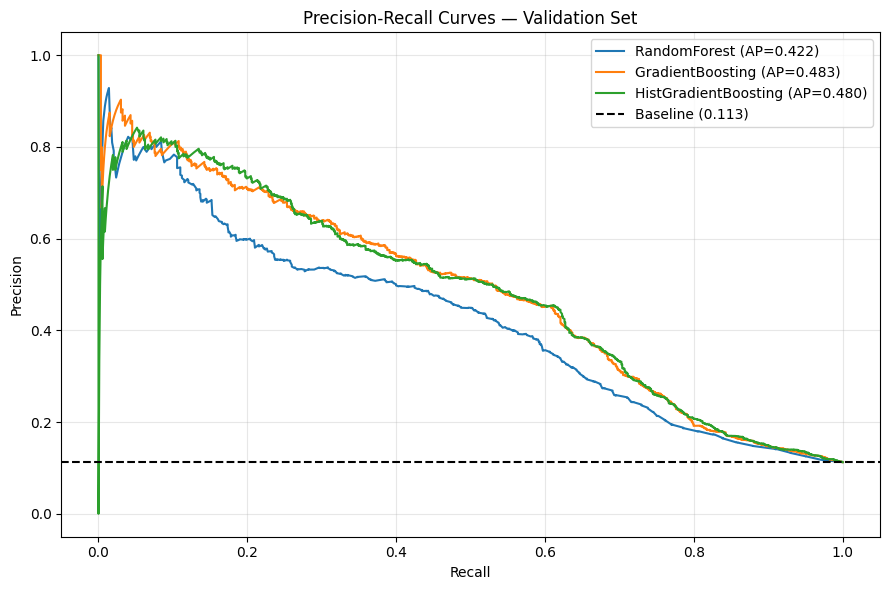

In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(9, 6))

for name, pipe in trained_models.items():
    probs = pipe.predict_proba(X_val)[:, 1]
    precision, recall, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')

plt.axhline(y_val.mean(), color='black', linestyle='--', label=f'Baseline ({y_val.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Validation Set')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4d. Hyperparameter Tuning
RandomizedSearchCV on the best model. Scoring on AUC to stay threshold-agnostic during search.

In [25]:
from sklearn.model_selection import RandomizedSearchCV

# HistGBM-specific hyperparameter grid
param_grid = {
    "classifier__max_iter":         [100, 200, 300, 400],
    "classifier__learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth":        [3, 4, 5, 6, None],
    "classifier__min_samples_leaf": [10, 20, 30, 50],
    "classifier__l2_regularization":[0.0, 0.1, 0.5, 1.0],
    "classifier__max_leaf_nodes":   [15, 31, 63, None],
}

base_tune_pipe = make_pipeline(
    HistGradientBoostingClassifier(random_state=42)
)

search = RandomizedSearchCV(
    base_tune_pipe,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
print(f"Best CV AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best CV AUC: 0.7933
Best params: {'classifier__min_samples_leaf': 30, 'classifier__max_leaf_nodes': 15, 'classifier__max_iter': 200, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05, 'classifier__l2_regularization': 0.0}


In [26]:
# Evaluate best model on val set
best_pipe = search.best_estimator_
val_probs_tuned = best_pipe.predict_proba(X_val)[:, 1]
val_auc_tuned = roc_auc_score(y_val, val_probs_tuned)
print(f'Tuned val AUC: {val_auc_tuned:.4f}')

# Compare before vs after tuning
baseline_auc = comparison_df[comparison_df['model'] == best_model_name]['val_auc'].values[0]
print(f'Baseline val AUC: {baseline_auc:.4f}')
print(f'Improvement: +{val_auc_tuned - baseline_auc:.4f}')

Tuned val AUC: 0.8105
Baseline val AUC: 0.8092
Improvement: +0.0013


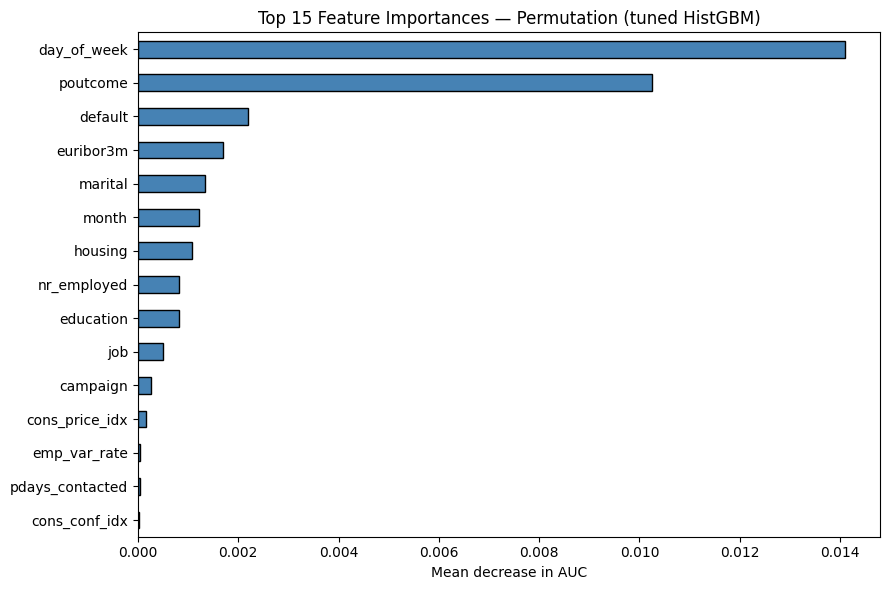

In [27]:
# Feature importance via permutation (works for all sklearn estimators)
from sklearn.inspection import permutation_importance

best_pipe = search.best_estimator_
result = permutation_importance(
    best_pipe, X_val, y_val,
    n_repeats=10, random_state=42, n_jobs=-1
)
importances = pd.Series(
    result.importances_mean, index=NUMERIC_COLS + CAT_COLS
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.head(15).sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Top 15 Feature Importances — Permutation (tuned HistGBM)")
plt.xlabel("Mean decrease in AUC")
plt.tight_layout()
plt.show()

## 4e. Final Pipeline
Build the final pipeline using the best hyperparameters found. This replaces section 5.

In [28]:
# Build final pipeline with best params + best imbalance strategy
best_params = {
    k.replace("classifier__", ""): v
    for k, v in search.best_params_.items()
}
print("Final model params:", best_params)

if "SMOTE" in best_name:
    pipeline = make_smote_pipeline(
        HistGradientBoostingClassifier(**best_params, random_state=42)
    )
elif "class_weight" in best_name:
    pipeline = make_pipeline(
        HistGradientBoostingClassifier(**best_params, class_weight="balanced", random_state=42)
    )
else:
    pipeline = make_pipeline(
        HistGradientBoostingClassifier(**best_params, random_state=42)
    )

pipeline.fit(X_train, y_train)
print("Final pipeline trained")

Final model params: {'min_samples_leaf': 30, 'max_leaf_nodes': 15, 'max_iter': 200, 'max_depth': 5, 'learning_rate': 0.05, 'l2_regularization': 0.0}
Final pipeline trained


In [29]:
## 4f. Re-tune threshold on final pipeline
# The tuned model has different probabilities — re-run threshold search
from sklearn.metrics import recall_score

final_val_probs = pipeline.predict_proba(X_val)[:, 1]

operating_threshold = 0.5
for t in np.arange(0.95, 0.00, -0.01):
    threshold = round(float(t), 2)
    preds = (final_val_probs >= threshold).astype(int)
    if recall_score(y_val, preds, zero_division=0) >= 0.75:
        operating_threshold = threshold
        break

print(f"Final operating threshold: {operating_threshold}")
print(f"(previous threshold from smote-pick was based on un-tuned model)")

Final operating threshold: 0.37
(previous threshold from smote-pick was based on un-tuned model)


## 7. Test Set Evaluation

In [30]:
from sklearn.metrics import roc_auc_score, classification_report

test_probs = pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= operating_threshold).astype(int)

test_auc = roc_auc_score(y_test, test_probs)
test_f1 = f1_score(y_test, test_preds, zero_division=0)
test_precision = precision_score(y_test, test_preds, zero_division=0)
test_recall = recall_score(y_test, test_preds, zero_division=0)

print(f"AUC:       {test_auc:.4f}")
print(f"F1:        {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print()
print(classification_report(y_test, test_preds))

AUC:       0.8143
F1:        0.3819
Precision: 0.2547
Recall:    0.7629

              precision    recall  f1-score   support

           0       0.96      0.72      0.82      7310
           1       0.25      0.76      0.38       928

    accuracy                           0.72      8238
   macro avg       0.61      0.74      0.60      8238
weighted avg       0.88      0.72      0.77      8238



## 8. Reference Stats for Drift Detection

In [31]:
import json

def compute_reference_stats(df_train, numeric_cols, cat_cols):
    stats = {
        "numeric_cols": numeric_cols,
        "cat_cols": cat_cols,
        "numerics": {},
        "categoricals": {},
        "output": {"positive_rate": float(y_train.mean())},
    }
    for col in numeric_cols:
        arr = df_train[col].dropna().to_numpy().astype(float)
        counts, bin_edges = np.histogram(arr, bins=10)
        stats["numerics"][col] = {
            "mean": float(df_train[col].mean()),
            "std": float(df_train[col].std()),
            "bin_edges": bin_edges.tolist(),
            "reference_pct": (counts / counts.sum()).tolist(),
        }
    for col in cat_cols:
        vc = df_train[col].value_counts(normalize=True)
        stats["categoricals"][col] = {k: float(v) for k, v in vc.items()}
    return stats

ref_stats = compute_reference_stats(X_train, NUMERIC_COLS, CAT_COLS)
print(json.dumps(ref_stats["numerics"]["age"], indent=2))

{
  "mean": 40.01355616704435,
  "std": 10.360087327841098,
  "bin_edges": [
    17.0,
    25.1,
    33.2,
    41.3,
    49.4,
    57.5,
    65.6,
    73.69999999999999,
    81.8,
    89.89999999999999,
    98.0
  ],
  "reference_pct": [
    0.040668501133052766,
    0.27642440919391387,
    0.2885237941081256,
    0.19889122693428293,
    0.1427241825833603,
    0.038523794108125606,
    0.00801230171576562,
    0.004289414049854322,
    0.0019019100032372936,
    4.046617028164455e-05
  ]
}


In [32]:
# Save locally (also logged to MLflow in section 9)
ref_stats_path = Path("reference_stats.json")
ref_stats_path.write_text(json.dumps(ref_stats, indent=2))
print(f"reference_stats.json saved to {ref_stats_path.resolve()}")

reference_stats.json saved to C:\Users\Kayan\OneDrive\Desktop\SE Factory\drift-triage-copilot\training\reference_stats.json


In [33]:
# Save fidelity reference predictions (gitignored â€” local only)
npy_path = Path("test_predictions_reference.npy")
np.save(str(npy_path), test_probs)
print(f"test_predictions_reference.npy saved")

test_predictions_reference.npy saved


## 9. Register in MLflow

In [34]:
import hashlib
import platform
import joblib
import mlflow
import mlflow.sklearn
import sklearn

MLFLOW_URI = "http://localhost:5000"
MODEL_NAME = "bank_churn_classifier"

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("drift-triage-training")
print("MLflow configured")

MLflow configured


In [35]:
import tempfile

# Compute model hash using a cross-platform temp directory
tmp_dir = Path(tempfile.mkdtemp())
model_local = tmp_dir / "model_pipeline.pkl"
joblib.dump(pipeline, model_local)
model_hash = hashlib.sha256(model_local.read_bytes()).hexdigest()
print(f"Model hash: {model_hash}")

Model hash: 770f81fd1bfae4567af98306035d9d67068a593ddd0b83683c78dd1b747a0ce8


In [36]:
with mlflow.start_run() as run:
    # Params
    mlflow.log_params({
        "model_type":        "HistGradientBoostingClassifier",
        "imbalance_strategy": best_name,
        "tuned_params":      str(best_params),
        "threshold":         operating_threshold,
        "train_rows":        len(X_train),
        "val_rows":          len(X_val),
        "test_rows":         len(X_test),
    })

    # Metrics
    mlflow.log_metrics({
        "test_auc":       test_auc,
        "test_f1":        test_f1,
        "test_precision": test_precision,
        "test_recall":    test_recall,
    })

    # Artifact 1: model (use name= not artifact_path= — required in MLflow 2.12+)
    mlflow.sklearn.log_model(pipeline, name="model")

    # Artifact 2: schema.json
    schema = {
        "feature_names": NUMERIC_COLS + CAT_COLS,
        "numeric_cols":  NUMERIC_COLS,
        "cat_cols":      CAT_COLS,
        "target":        TARGET,
    }
    schema_path = tmp_dir / "schema.json"
    schema_path.write_text(json.dumps(schema, indent=2))
    mlflow.log_artifact(str(schema_path), artifact_path="schema")

    # Artifact 3: model_card.json
    model_card = {
        "model_hash":        model_hash,
        "model_type":        "HistGradientBoostingClassifier",
        "imbalance_strategy": best_name,
        "python_version":    platform.python_version(),
        "sklearn_version":   sklearn.__version__,
        "training_date":     pd.Timestamp.utcnow().isoformat(),
        "dataset_rows":      len(df),
        "threshold":         operating_threshold,
        "test_auc":          test_auc,
        "test_f1":           test_f1,
        "test_recall":       test_recall,
        "test_precision":    test_precision,
        "model_name":        MODEL_NAME,
    }
    model_card_path = tmp_dir / "model_card.json"
    model_card_path.write_text(json.dumps(model_card, indent=2))
    mlflow.log_artifact(str(model_card_path), artifact_path="model_card")

    # Reference stats (model_service loads this at startup for drift detection)
    mlflow.log_artifact(str(ref_stats_path), artifact_path="reference_stats")

    run_id = run.info.run_id
    print(f"Run ID: {run_id}")

print("MLflow run complete")

2026/05/08 21:23:42 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Kayan\OneDrive\Desktop\SE Factory\drift-triage-copilot\training
2026/05/08 21:23:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 21:23:43 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Kayan\OneDrive\Desktop\SE Factory\drift-triage-copilot\training
2026/05/08 21:23:43 INFO mlflow.utils.environment: Detected uv project at c:\Users\Kayan\OneDrive\Desktop\SE Factory\drift-triage-copilot\training. Attempting to export requirements via 'uv export'.
2026/05/08 21:23:43 INFO mlflow.utils.uv_uti

Run ID: a17d03e57f1a4fe3a29ca3d87629acba
🏃 View run useful-robin-301 at: http://localhost:5000/#/experiments/762102991875273233/runs/a17d03e57f1a4fe3a29ca3d87629acba
🧪 View experiment at: http://localhost:5000/#/experiments/762102991875273233
MLflow run complete


In [37]:
# Register model and set staging alias
model_uri = f"runs:/{run_id}/model"
registered = mlflow.register_model(model_uri=model_uri, name=MODEL_NAME)
print(f"Registered version: {registered.version}")

client = mlflow.tracking.MlflowClient()
client.set_registered_model_alias(
    name=MODEL_NAME,
    alias="staging",
    version=registered.version,
)
print(f"Alias 'staging' set on version {registered.version}")

Registered model 'bank_churn_classifier' already exists. Creating a new version of this model...
2026/05/08 21:23:48 WARNING mlflow.tracking._model_registry.fluent: Run with id a17d03e57f1a4fe3a29ca3d87629acba has no artifacts at artifact path 'model', registering model based on models:/m-aa7fac9846f547248f03ec6be90f7a8d instead
2026/05/08 21:23:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bank_churn_classifier, version 5
Created version '5' of model 'bank_churn_classifier'.


Registered version: 5
Alias 'staging' set on version 5


## 10. Verify

In [38]:
# Verify model loads back and predictions match to 1e-12
loaded = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}@staging")
loaded_probs = loaded.predict_proba(X_test)[:, 1]
assert np.allclose(loaded_probs, test_probs, atol=1e-12), "Fidelity check failed!"
print("Fidelity check passed â€” predictions match to 1e-12")

Fidelity check passed â€” predictions match to 1e-12


In [39]:
# Verify all artifacts exist
artifacts = client.list_artifacts(run_id)
artifact_paths = [a.path for a in artifacts]
print("Artifacts:", artifact_paths)
assert "schema" in artifact_paths,      "Missing schema artifact"
assert "model_card" in artifact_paths,  "Missing model_card artifact"
assert "reference_stats" in artifact_paths, "Missing reference_stats artifact"
# model is stored via the Models API (name=), not as a run artifact path
loaded_model = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}@staging")
assert loaded_model is not None, "Model not loadable from registry"
print("All artifacts verified")

Artifacts: ['model_card', 'reference_stats', 'schema']


All artifacts verified
